In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ticker = "aapl"
data = yf.download(
    ticker,
    start = "2020-01-01",
    end = "2025-01-01",
    auto_adjust = True
)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [ ]:
close = data["Close"].squeeze()

data["ma50"] = close.rolling(50).mean()
data["ma200"] = close.rolling(200).mean()

In [ ]:
data[["Close","ma50","ma200"]].tail()

Price,Close,ma50,ma200
Ticker,AAPL,,
Date,,,
2024-12-24,256.560822,234.325890,210.072593
2024-12-26,257.375641,234.831201,210.501923
2024-12-27,253.967377,235.309440,210.924607
2024-12-30,250.598907,235.712965,211.321192
2024-12-31,248.830231,236.024540,211.710815


In [ ]:
data["signal"] = 0
data.loc[
    data["ma50"] > data["ma200"],
    "signal"
] = 1

In [ ]:
Close = data["Close"].squeeze()
data["market_return"] = close.pct_change()


In [ ]:
data["strategy_return"] = (
    data["signal"].shift(1)
    *data["market_return"]
)

In [ ]:
data["market_cumulative"] = (
    1 + data["market_return"]
).cumprod()
data["strategy_cumulative"] = (
    1 + data["strategy_return"]
).cumprod()

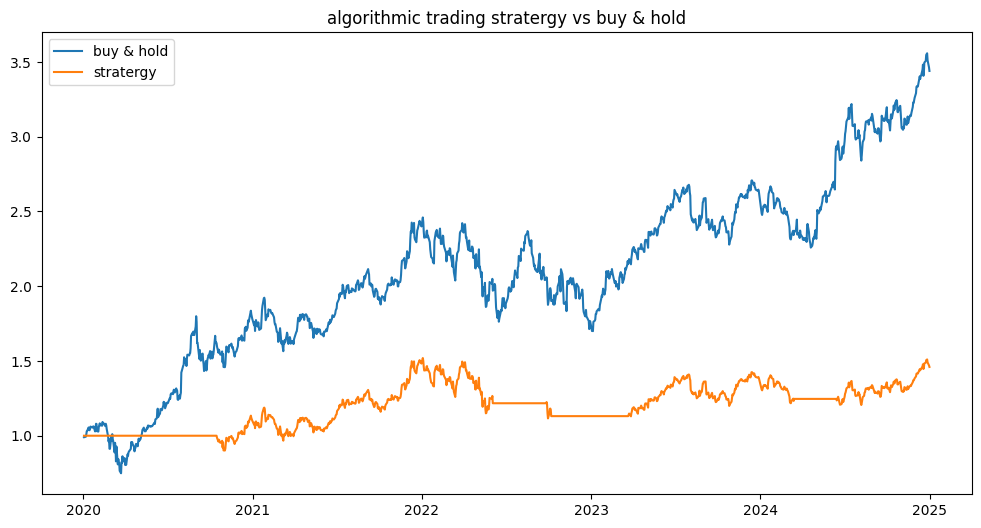

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(
    data.index,
    data["market_cumulative"],
    label = "buy & hold"
)
plt.plot(
    data.index,
    data["strategy_cumulative"],
    label = "stratergy"
)
plt.title(
    "algorithmic trading stratergy vs buy & hold"
)
plt.legend()
plt.show()

In [ ]:
buy_hold_return = (
    data["market_cumulative"].iloc[-1] - 1
) * 100

strategy_return = (
    data["strategy_cumulative"].iloc[-1] - 1
) * 100

print("buy & hold return:", round(buy_hold_return,2), "%")
print("strategy return:", round(strategy_return,2), "%")

buy & hold return: 244.0 %
strategy return: 46.01 %


In [ ]:
sharpe = (
    data["strategy_return"].mean()
    /
    data["strategy_return"].std()
) * np.sqrt(252)

print("sharpe ratio:", round(sharpe,2))

sharpe ratio: 0.48


In [ ]:
rolling_max = (
    data["strategy_cumulative"]
    .cummax()
)

drawdown = (
    data["strategy_cumulative"]
    - rolling_max
) / rolling_max

max_drawdown = drawdown.min()

print(
    "maximum drawdown:",
    round(max_drawdown*100,2),
    "%"
)

maximum drawdown: -26.58 %


In [ ]:
data["position"] = data["signal"].diff()

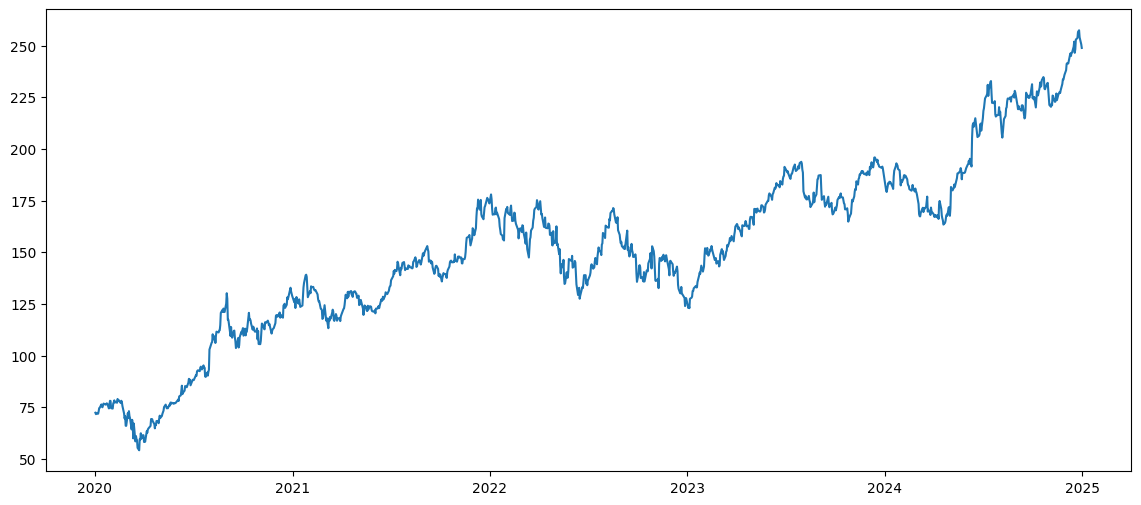

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    data.index,
    data["Close"],
    label="aapl price"
)

buy = data[data["position"] == 1]

sell = data[data["position"] == -1]

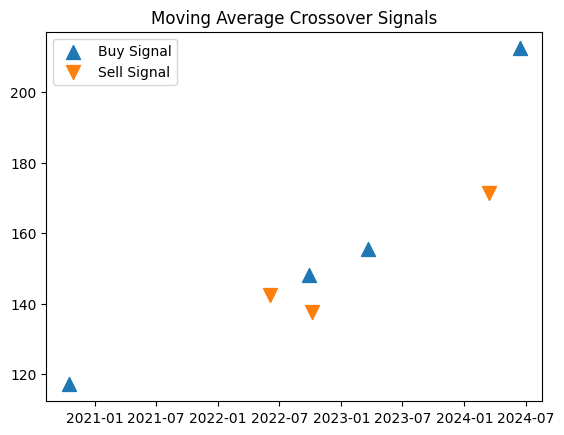

In [ ]:
plt.scatter(
    buy.index,
    buy["Close"],
    marker="^",
    s=100,
    label="Buy Signal"
)

plt.scatter(
    sell.index,
    sell["Close"],
    marker="v",
    s=100,
    label="Sell Signal"
)

plt.title(
    "Moving Average Crossover Signals"
)

plt.legend()

plt.show()